# Problem 1
## 1.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
import numpy as np

data = pd.read_csv("./data/passengercarmileage.txt", sep="\t", index_col=0)
data

,VOL,HP,MPG,SP,WT
makeAndModel,,,,,
GM/GeoMetroXF1,89,49,65.4,96,17.5
GM/GeoMetro,92,55,56.0,97,20.0
GM/GeoMetroLSI,92,55,55.9,97,20.0
SuzukiSwift,92,70,49.0,105,20.0
DaihatsuCharade,92,53,46.5,96,20.0
...,...,...,...,...,...
Mercedes500SL,50,322,18.1,165,45.0
Mercedes560SEL,115,238,17.2,140,45.0
JaguarXJSConvert,50,263,17.0,147,45.0


                            OLS Regression Results                            
Dep. Variable:                    MPG   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     132.7
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           1.15e-18
Time:                        01:07:43   Log-Likelihood:                -264.61
No. Observations:                  82   AIC:                             533.2
Df Residuals:                      80   BIC:                             538.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     50.0661      1.569     31.900      0.0

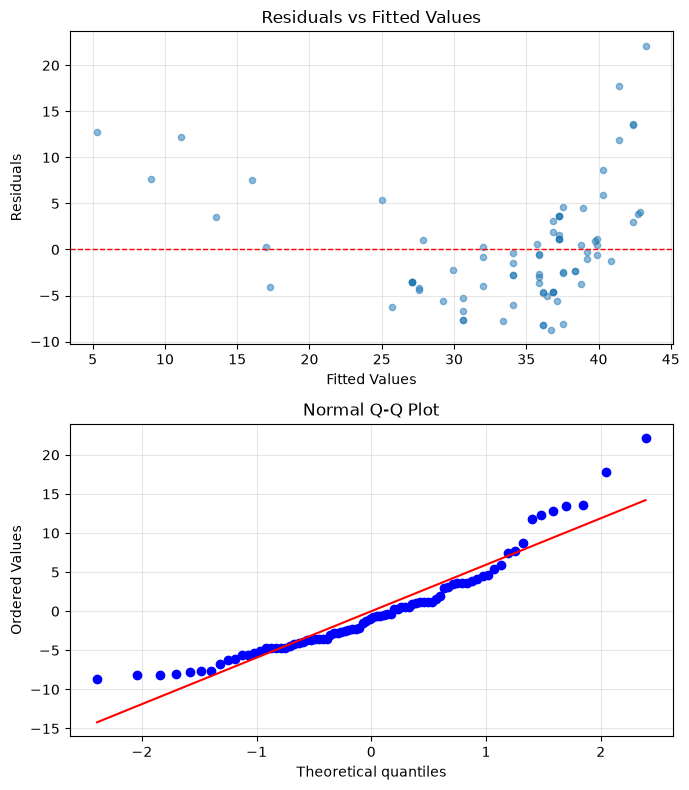

In [38]:
model = smf.ols("MPG ~ HP", data=data)
results = model.fit()
print(results.summary())
residuals = results.resid
fitted = results.fittedvalues

# Create diagnostic plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8))

# Get residuals and fitted values
residuals = results.resid
fitted = results.fittedvalues

# Plot 1: Residuals vs Fitted Values
ax1.scatter(fitted, residuals, alpha=0.5, s=20)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted Values')
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q plot for normality check
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Normal Q-Q Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.


Slope: -0.00459
                            OLS Regression Results                            
Dep. Variable:                log_MPG   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     221.2
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           9.62e-25
Time:                        01:07:43   Log-Likelihood:                 36.047
No. Observations:                  82   AIC:                            -68.09
Df Residuals:                      80   BIC:                            -63.28
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.0132      0.040    

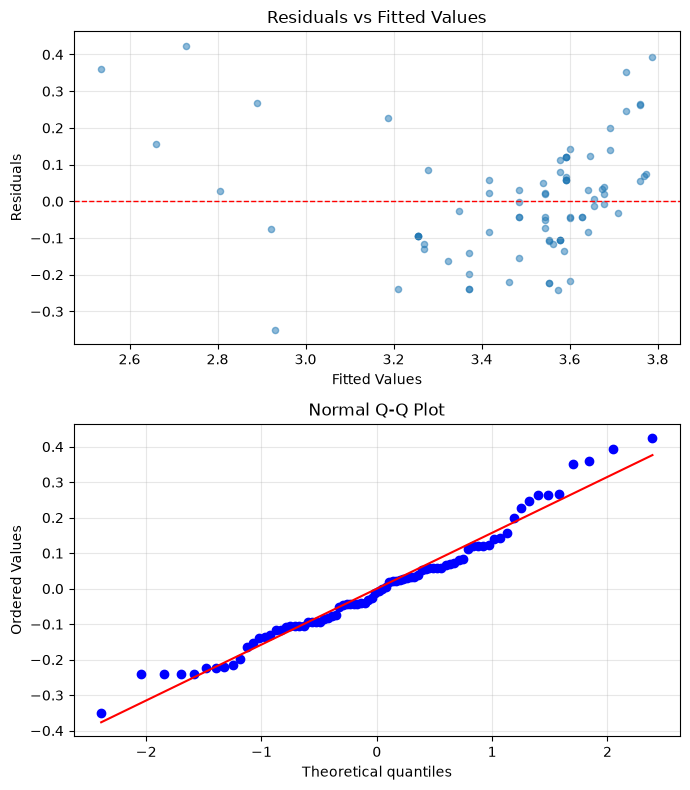

In [39]:
data["log_MPG"] = np.log(data["MPG"])
model = smf.ols("log_MPG ~ HP", data=data)
results = model.fit()
print(f"Slope: {results.params["HP"]:.5f}")
print(results.summary())
residuals = results.resid
fitted = results.fittedvalues

# Create diagnostic plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8))

# Get residuals and fitted values
residuals = results.resid
fitted = results.fittedvalues

# Plot 1: Residuals vs Fitted Values
ax1.scatter(fitted, residuals, alpha=0.5, s=20)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted Values')
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q plot for normality check
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Normal Q-Q Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.

                            OLS Regression Results                            
Dep. Variable:                    MPG   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     132.7
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           9.98e-34
Time:                        01:07:43   Log-Likelihood:                -220.00
No. Observations:                  82   AIC:                             450.0
Df Residuals:                      77   BIC:                             462.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    192.4378     23.532      8.178      0.0

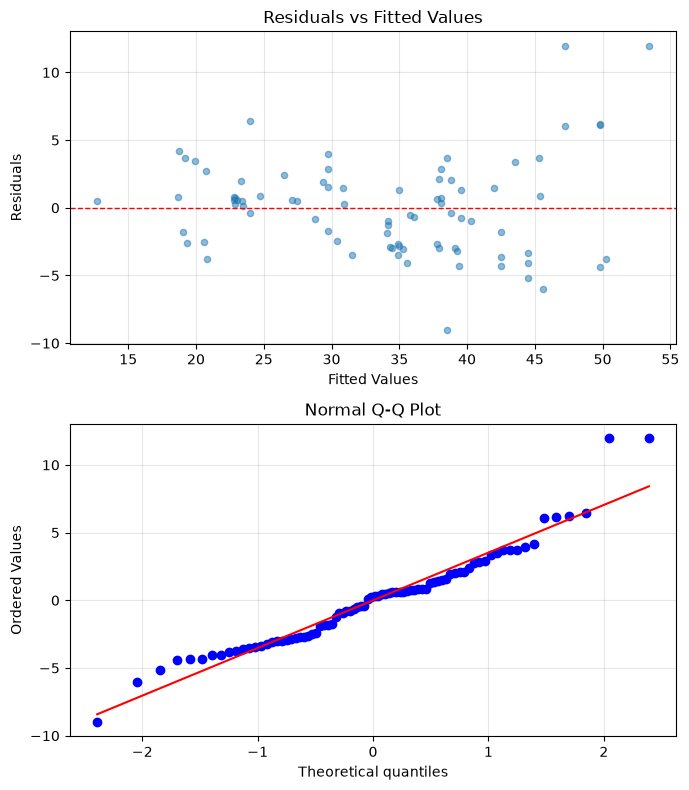

In [40]:
model = smf.ols("MPG ~ HP + VOL + SP + WT", data=data)
results = model.fit()
print(results.summary())
residuals = results.resid
fitted = results.fittedvalues

# Create diagnostic plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8))

# Get residuals and fitted values
residuals = results.resid
fitted = results.fittedvalues

# Plot 1: Residuals vs Fitted Values
ax1.scatter(fitted, residuals, alpha=0.5, s=20)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted Values')
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q plot for normality check
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Normal Q-Q Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Problem 2
## 1.

We have $Y_i = \beta X_i  + \epsilon_i$, where $\epsilon_i$ are i.i.d. and $X_i,\dots,X_n$, $Y_i,\dots,Y_n$. We want to minimize the residual sum of squares
$$
\text{RSS}=\sum_{i=1}^n \hat{\epsilon}_i^2 = \sum_{i=1}^n (Y_i - \hat{\beta}X_i)^2.
$$
Taking the derivative w.r.t. $\hat{\beta}$ and setting it to zero, we find
$$
\begin{align*}
\frac{\partial \text{RSS}}{\partial \hat{\beta}} &= -2 \sum_{i=1}^n X_i(Y_i - \hat{\beta}X_i) = 0 \\
\implies \sum_{i=1}^n X_i Y_i &= \hat{\beta}\sum_{i=1}^n X_i^2 \\
\implies \hat{\beta} &= \frac{\sum_{i=1}^n X_i Y_i}{\sum_{i=1}^n X_i^2}.
\end{align*}
$$

## 2.
Substitute the equation for $Y_i$ into the least squares estimate
$$
\begin{align*}
\hat{\beta} &= \frac{\sum_{i=1}^n X_i Y_i}{\sum_{i=1}^n X_i^2} \\
&= \frac{\sum_{i=1}^n X_i (\beta X_i + \epsilon_i)}{\sum_{i=1}^n X_i^2} \\
&= \beta\frac{\sum_{i=1}^n X_i^2}{\sum_{i=1}^n X_i^2} + \frac{\sum_{i=1}^n X_i \epsilon_i}{\sum_{i=1}^n X_i^2} \\
&= \beta + \frac{\sum_{i=1}^n X_i \epsilon_i}{\sum_{i=1}^n X_i^2}.
\end{align*}
$$
Since $\mathbb{E}(X_i\epsilon_i)=0$, the second term vanishes when we take the expectation $\mathbb{E}(\hat{\beta})$, and thus $\mathbb{E}(\hat{\beta})=\beta$. The bias is then $\text{bias}(\hat{\beta})=\mathbb{E}(\hat{\beta})-\beta=\beta - \beta=0$.

# Problem 3
## 1.

Starting MCMC sampling...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


Sampling complete!
         mean      sd  eti89_lb  eti89_ub   ess_bulk   ess_tail   r_hat  \
theta  0.1298  0.1969   -0.1816     0.444  1805.0898  2374.1641  1.0005   

       mcse_mean  mcse_sd  
theta     0.0047   0.0028  


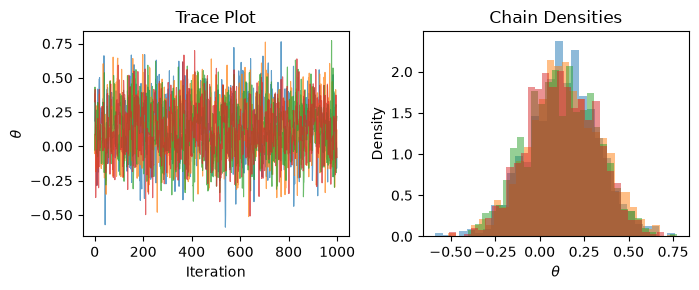

In [41]:
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

# --- Data and Hyperparameters ---
X_data = np.array([-0.02, -0.03, 0.82, -1.05, -0.76, 0.46, -0.06, 0.34, -0.08,
                    -0.24, 1.43, 1.07, -2.5 , 1.48, 2.16, 1.23, -0.21, -0.69, 0.73, -0.62]) # The observed data
sigma_known = 1.0        # Standard deviation for data (known)
theta_mean = 0.0         # Prior mean for theta
theta_std = 0.4          # Prior standard deviation for theta

# --- Model Definition ---
with pm.Model() as model_part_a:
    # Prior for theta
    theta = pm.Normal('theta', mu=theta_mean, sigma=theta_std)

    # Likelihood of the data
    X_obs = pm.Normal('X_obs', mu=theta, sigma=sigma_known, observed=X_data)

    # Sample from posterior using NUTS
    print("Starting MCMC sampling...")
    idata = pm.sample(draws=1000, tune=1000, random_seed=42, progressbar=False)
    print("Sampling complete!")

print(az.summary(idata, round_to=4))

# Create trace plot for visual inspection
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Extract theta samples for all chains
theta_samples = idata.posterior["theta"].values

# Plot traces for each chain
for chain in range(theta_samples.shape[0]):
    axes[0].plot(theta_samples[chain, :], alpha=0.7, linewidth=0.8)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel(r"$\theta$")
axes[0].set_title("Trace Plot")

# Plot overlaid densities
for chain in range(theta_samples.shape[0]):
    axes[1].hist(theta_samples[chain, :], bins=30, alpha=0.5, density=True)
axes[1].set_xlabel(r"$\theta$")
axes[1].set_ylabel("Density")
axes[1].set_title("Chain Densities")

plt.tight_layout()
plt.show()


## 2.

Initializing NUTS using jitter+adapt_diag...


Starting MCMC sampling...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Sampling complete!
         mean      sd  eti89_lb  eti89_ub   ess_bulk   ess_tail   r_hat  \
theta  0.1311  0.2006   -0.1887    0.4494  3577.1896  2616.5685  1.0008   
sigma  1.0882  0.1768    0.8483    1.3948  2803.0687  2549.1384  1.0009   

       mcse_mean  mcse_sd  
theta     0.0034   0.0036  
sigma     0.0034   0.0036  


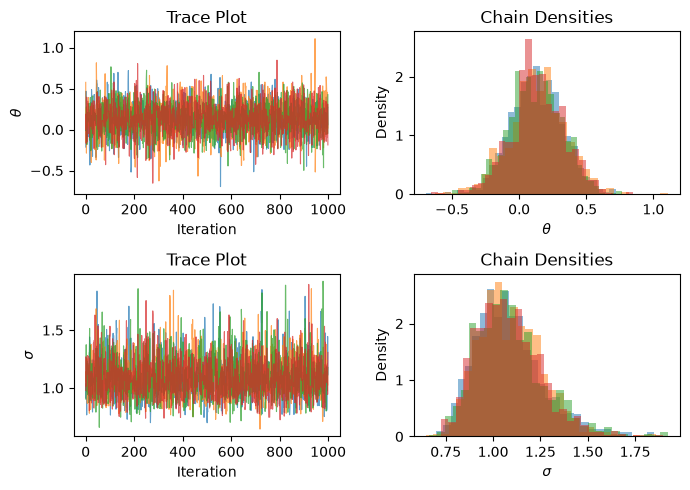

In [42]:
with pm.Model() as model_part_b:
    # Prior for theta
    theta = pm.Normal('theta', mu=theta_mean, sigma=theta_std)
    # Prior for sigma
    sigma = pm.Gamma("sigma", alpha=2, beta=2)
    # Likelihood of the data
    X_obs = pm.Normal('X_obs', mu=theta, sigma=sigma, observed=X_data)

    # Sample from posterior using NUTS
    print("Starting MCMC sampling...")
    idata = pm.sample(draws=1000, tune=1000, random_seed=42, progressbar=False)
    print("Sampling complete!")

print(az.summary(idata, round_to=4))

# Create trace plot for visual inspection
fig, axes = plt.subplots(2, 2, figsize=(7, 5))

# Extract theta samples for all chains
theta_samples = idata.posterior["theta"].values
sigma_samples = idata.posterior["sigma"].values

# Plot traces for each chain
for chain in range(theta_samples.shape[0]):
    axes[0, 0].plot(theta_samples[chain, :], alpha=0.7, linewidth=0.8)
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].set_ylabel(r"$\theta$")
axes[0, 0].set_title("Trace Plot")

# Plot overlaid densities
for chain in range(theta_samples.shape[0]):
    axes[0, 1].hist(theta_samples[chain, :], bins=30, alpha=0.5, density=True)
axes[0, 1].set_xlabel(r"$\theta$")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Chain Densities")

# Plot traces for each chain
for chain in range(sigma_samples.shape[0]):
    axes[1, 0].plot(sigma_samples[chain, :], alpha=0.7, linewidth=0.8)
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel(r"$\sigma$")
axes[1, 0].set_title("Trace Plot")

# Plot overlaid densities
for chain in range(sigma_samples.shape[0]):
    axes[1, 1].hist(sigma_samples[chain, :], bins=30, alpha=0.5, density=True)
axes[1, 1].set_xlabel(r"$\sigma$")
axes[1, 1].set_ylabel("Density")
axes[1, 1].set_title("Chain Densities")
plt.tight_layout()
plt.show()

# Problem 4
## 1.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, sigma]
/home/macpalor/miniforge3/envs/stats4ds/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
beta0  0.217  0.841    -1.153     1.550  1750.584  1515.627  1.002      0.020   
beta1  0.791  0.171     0.525     1.064  1796.122  2169.696  1.002      0.004   
sigma  2.339  0.501     1.690     3.234  2077.627  2198.769  1.004      0.011   

       mcse_sd  
beta0    0.015  
beta1    0.003  
sigma    0.011  


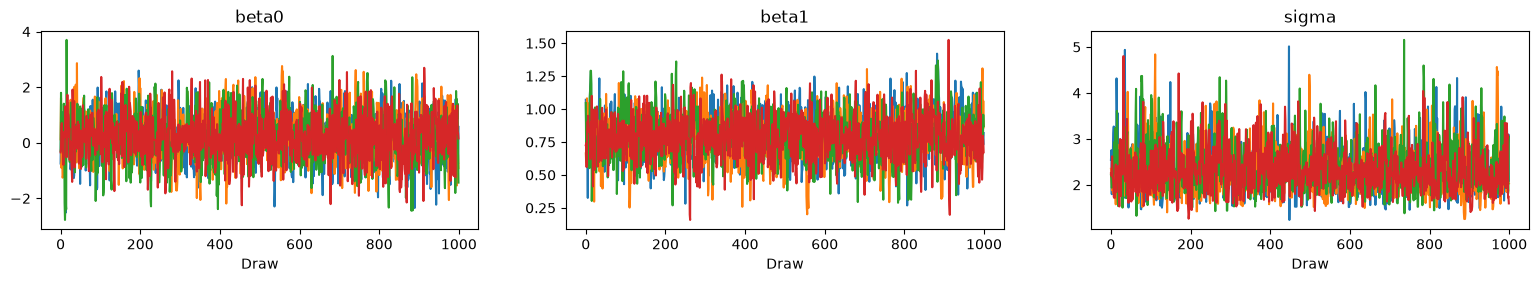

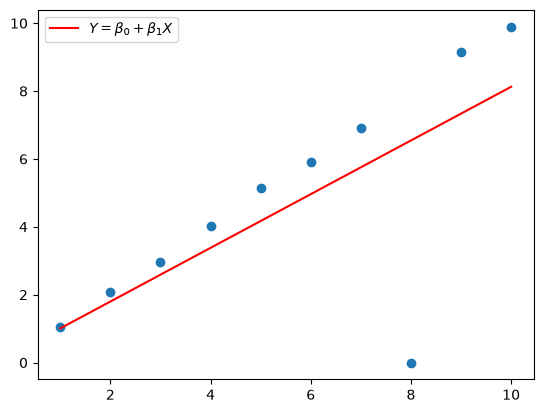

In [51]:
# --- Data and Hyperparameters ---
# The data for the exercise
X_data = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
Y_data = np.array([1.06, 2.07, 2.97, 4.01, 5.13, 5.92, 6.91, 0.00, 9.15, 9.90])

# Prior hyperparameters
beta_mean = 0.0
beta_std = 1.0
sigma_alpha = 0.1
sigma_beta = 1.0

# --- Model Definition ---
with pm.Model() as linear_model:
    # Priors for the intercept (beta0) and slope (beta1)
    beta0 = pm.Normal('beta0', mu=beta_mean, sigma=beta_std)
    beta1 = pm.Normal('beta1', mu=beta_mean, sigma=beta_std)
    
    # Prior for the noise standard deviation
    sigma = pm.Gamma('sigma', alpha=sigma_alpha, beta=sigma_beta)
    
    # Expected value of Y
    mu = beta0 + beta1 * X_data
    
    # Likelihood of the data
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma, observed=Y_data)
    idata = pm.sample(draws=1000, tune=1000, random_seed=42, progressbar=False)

summary = az.summary(idata, round_to=3)
print(summary)
az.plot_trace(idata)
plt.show()

slope = summary.loc["beta1", "mean"]
intercept = summary.loc["beta0", "mean"]

plt.scatter(X_data, Y_data)
x = np.linspace(X_data.min(), X_data.max(), 100)
y = slope * x + intercept
plt.plot(x, y, "r", label=r"$Y=\beta_0 + \beta_1 X$")
plt.legend()
plt.show()

## 2.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, sigma]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


         mean      sd  eti89_lb  eti89_ub   ess_bulk   ess_tail   r_hat  \
beta0  0.0623  0.1061   -0.1015    0.2201  2416.3554  2528.9393  1.0009   
beta1  0.9888  0.0194    0.9614    1.0194  2361.5097  2354.8648  1.0014   
sigma  0.1403  0.0727    0.0644    0.2692   965.3975   928.7685  1.0012   

       mcse_mean  mcse_sd  
beta0     0.0023   0.0033  
beta1     0.0004   0.0006  
sigma     0.0018   0.0025  


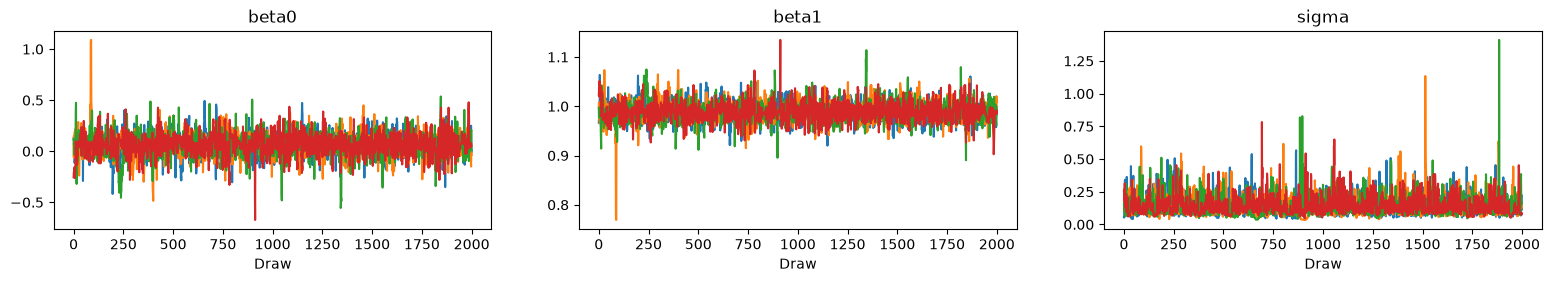

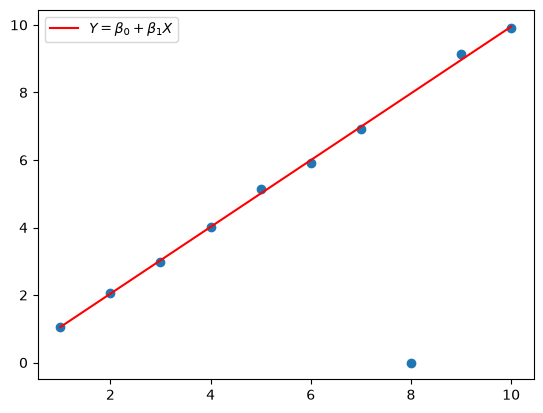

In [56]:
# --- Model Definition ---
with pm.Model() as linear_model:
    # Priors for the intercept (beta0) and slope (beta1)
    beta0 = pm.Normal('beta0', mu=beta_mean, sigma=beta_std)
    beta1 = pm.Normal('beta1', mu=beta_mean, sigma=beta_std)
    
    # Prior for the noise standard deviation
    sigma = pm.Gamma('sigma', alpha=sigma_alpha, beta=sigma_beta)
    
    # Expected value of Y
    mu = beta0 + beta1 * X_data
    
    # Likelihood of the data
    Y_obs = pm.StudentT('Y_obs', nu=3, mu=mu, sigma=sigma, observed=Y_data)
    idata = pm.sample(draws=2000, tune=1000, random_seed=42, progressbar=False)

summary = az.summary(idata, round_to=4)
print(summary)
az.plot_trace(idata)
plt.show()

slope = summary.loc["beta1", "mean"]
intercept = summary.loc["beta0", "mean"]

plt.scatter(X_data, Y_data)
x = np.linspace(X_data.min(), X_data.max(), 100)
y = slope * x + intercept
plt.plot(x, y, "r", label=r"$Y=\beta_0 + \beta_1 X$")
plt.legend()
plt.show()